# 实习一：数据库应用案例设计

项目：璨宇国际仓储与拼柜系统

### 项目说明

本项目基于真实业务需求场景开发（国际仓储、入库、拼柜、结算与报表流程）。

完整项目代码仓库（GitHub）：
- https://github.com/eureka-s1/DataBase

说明：本 Notebook 主要用于课程提交展示核心功能与设计思路，完整工程代码、脚本与页面实现请以上述仓库为准。




## 1. 需求分析

### 1.1 系统基础
1. 单机运行。
2. 数据自动备份与恢复。
3. 管理员登录、退出与改密。
4. 客户主数据维护（姓名、电话、国家、邮箱）。
5. 默认价格设置与临时调价。

### 1.2 入库管理
1. 支持 Excel 收货清单导入。
2. 支持手工录入单条货物。
3. 自动计算体积：长 × 宽 × 高 ÷ 1000000。
4. 入库默认状态为在库（IN_STOCK）。
5. 支持按日期、客户查询、修改与删除。

### 1.3 拼柜管理
1. 新建柜次。
2. 装柜与容量校验（默认 68 CBM）。
3. 支持手工调整装柜体积。
4. 确认出柜后状态变更为已出柜。
5. 支持撤回柜次并恢复货物状态。

### 1.4 费用结算
1. 记录客户收款流水与支付方式。
2. 按柜次体积自动计算运费。
3. 自动抵扣客户定金。
4. 生成结算单并支持过账/反过账。

### 1.5 报表与运维
1. 按日入库清单。
2. 当前库存清单。
3. 客户总账。
4. Excel / PDF 导出。
5. 数据库备份与恢复。


## 2. 数据库设计与 ER 图

### 2.1 核心实体
- users（用户与权限）
- customers（客户主数据）
- customer_aliases（客户别名）
- customer_price_rules（客户价格规则）
- warehouses（仓库）
- import_batches（导入批次）
- inbound_items（入库明细）
- containers（货柜）
- container_items（装柜明细）
- payment_transactions（收款流水）
- settlement_statements（结算单）
- settlement_lines（结算明细）
- payment_allocations（收款分配）

### 2.2 关键关系
- customers 1:N inbound_items
- customers 1:N customer_aliases
- customers 1:N customer_price_rules
- warehouses 1:N inbound_items
- import_batches 1:N inbound_items
- containers 1:N container_items
- inbound_items 1:N container_items
- containers 1:N settlement_statements
- settlement_statements 1:N settlement_lines
- payment_transactions N:M settlement_lines（通过 payment_allocations）

### 2.3 关系模式落地
- 建表 SQL：`schema/schema.sql`
- 业务实现：`app/services/*.py`


### ER 图

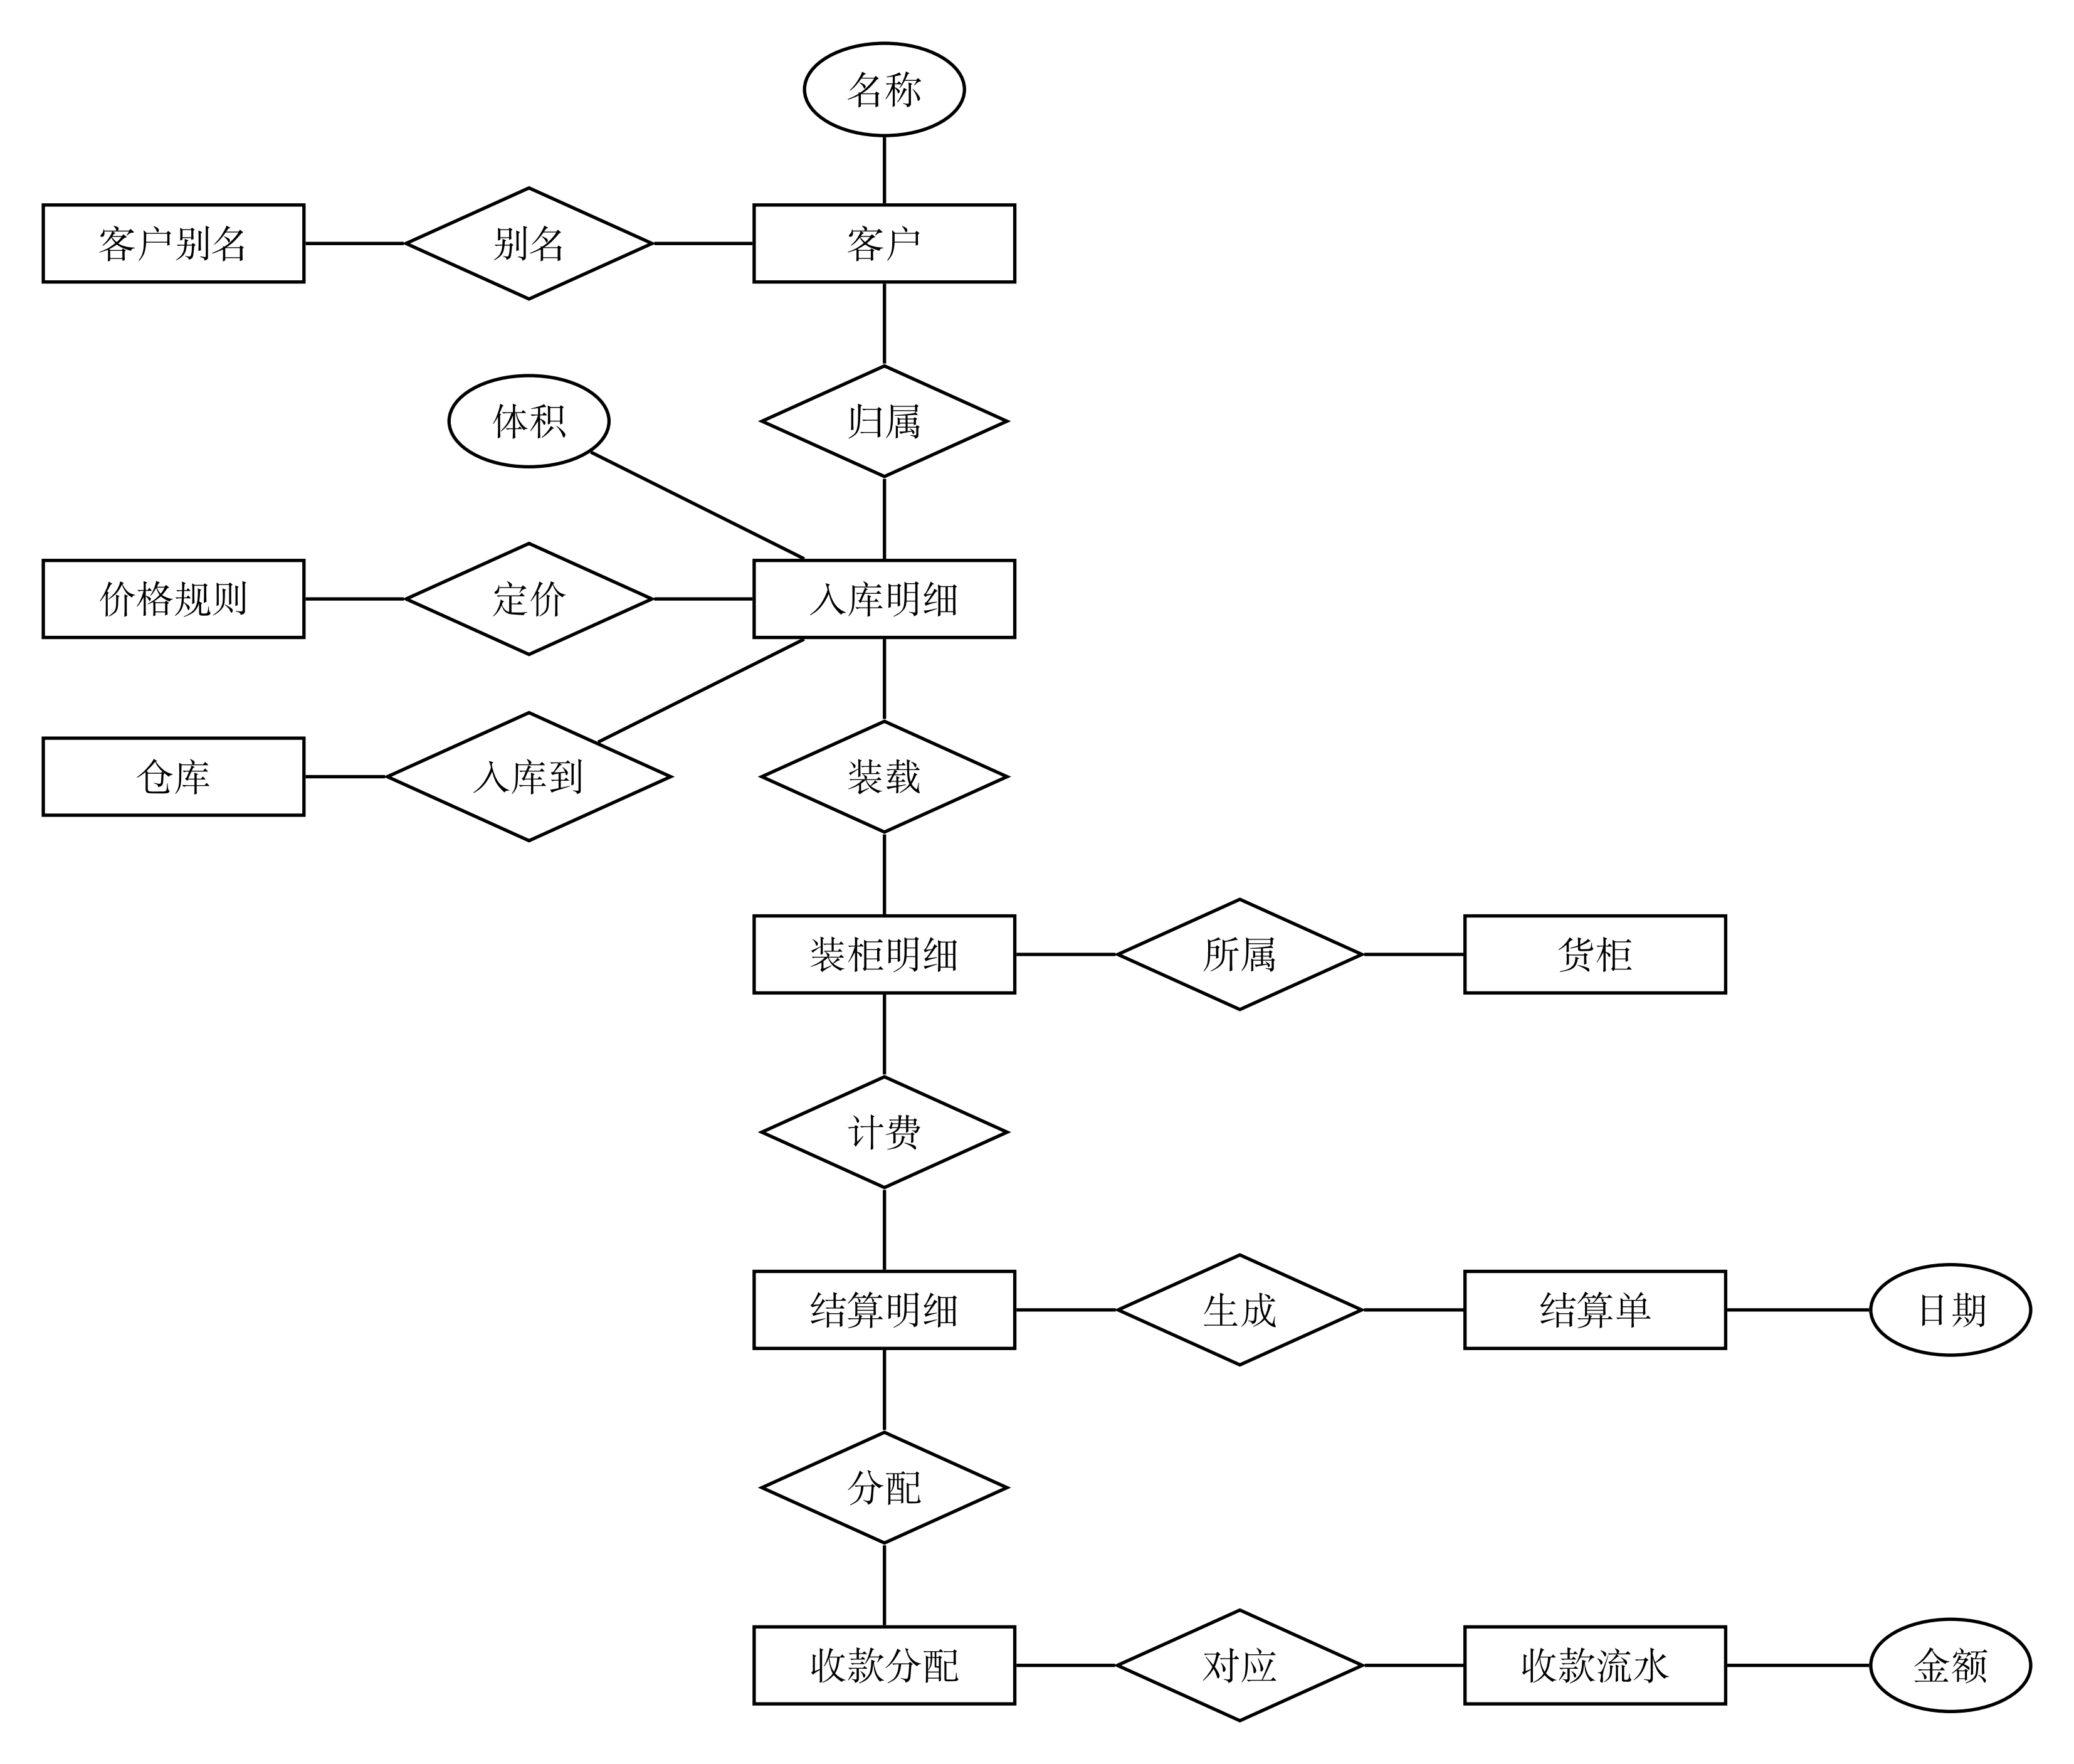


## 3. 创建数据库


In [ ]:
from app.config import DB_PATH
from app.db import init_db

if DB_PATH.exists():
    DB_PATH.unlink()
init_db()
print('DB initialized at:', DB_PATH)


In [ ]:
import sqlite3
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()
print('table_count =', len(rows))
print([r['name'] for r in rows])


In [ ]:
summary = conn.execute("""
SELECT
  (SELECT COUNT(*) FROM customers) AS customers,
  (SELECT COUNT(*) FROM inbound_items) AS inbound_items,
  (SELECT COUNT(*) FROM containers) AS containers,
  (SELECT COUNT(*) FROM payment_transactions) AS payments,
  (SELECT COUNT(*) FROM settlement_statements) AS statements
""").fetchone()
print(dict(summary))


## 4. SQL 操作与 PySQLite CRUD

课程要求：给出业务 SQL，并通过 PySQLite 完成增删改查。
下面通过 Flask Test Client 驱动真实业务接口，覆盖核心 CRUD 与流程。


In [ ]:
from app import create_app

app = create_app()
client = app.test_client()

def j(resp):
    try:
        return resp.get_json()
    except Exception:
        return {'raw': resp.get_data(as_text=True)[:300]}

r = client.post('/login', json={'username': 'admin', 'password': 'admin123'})
print('login:', r.status_code, j(r))

r = client.post('/customers', json={
    'customer_code': 'NB-FINAL-001',
    'name': 'MARTIN',
    'phone': '0800000000',
    'country': 'Nigeria',
    'email': 'martin@example.com',
    'default_price_per_m3': 89.71,
})
customer_id = j(r)['id']
print('create customer:', r.status_code, j(r))

r = client.post('/customer-aliases', json={
    'customer_id': customer_id,
    'alias_name': 'MARTIN STORE',
    'source': 'MANUAL',
})
print('upsert alias:', r.status_code, j(r))

r = client.post('/inbound-items', json={
    'inbound_no': 'NB-FINAL-IN-001',
    'customer_id': customer_id,
    'warehouse_id': 1,
    'inbound_date': '2026-04-11',
    'shop_no': 'A1',
    'position_or_tel': 'P1',
    'item_no': 'IT-001',
    'item_name_cn': '杯子',
    'material': '塑料',
    'carton_count': 2,
    'qty': 20,
    'length_cm': 50,
    'width_cm': 40,
    'height_cm': 30,
})
item_id = j(r)['id']
print('create inbound:', r.status_code, j(r))

r = client.get('/inbound-items?only_in_stock=1')
print('in stock count:', len(j(r)))

r = client.put(f'/inbound-items/{item_id}', json={'remark': 'updated in notebook'})
print('update inbound:', r.status_code, j(r))

r = client.post('/containers', json={'container_no': 'NB-FINAL-CAB-001', 'capacity_cbm': 68})
container_id = j(r)['id']
print('create container:', r.status_code, j(r))
client.post(f'/containers/{container_id}/items', json={'inbound_item_id': item_id})
client.put(f'/containers/{container_id}/master-customer', json={'master_customer_id': customer_id})
print('usage:', client.get(f'/containers/{container_id}/usage').get_json())

r = client.post(f'/containers/{container_id}/confirm', json={})
print('confirm container:', r.status_code, j(r))

client.post('/payments', json={
    'payment_no': 'NB-FINAL-PAY-001',
    'customer_id': customer_id,
    'amount': 1000,
    'method': 'WECHAT',
})
r = client.post('/settlements/generate', json={'container_id': container_id, 'statement_date': '2026-04-11'})
statement_id = j(r)['statement_id']
print('generate statement:', r.status_code, j(r))
r = client.post(f'/settlements/{statement_id}/post', json={})
print('post statement:', r.status_code, j(r))

r = client.get('/ledger')
ledger_rows = j(r)
print('ledger rows:', len(ledger_rows))
print('ledger sample:', ledger_rows[0] if ledger_rows else {})


In [ ]:
print('daily inbound export:', client.post('/exports/daily-inbound', json={'inbound_date': '2026-04-11'}).get_json())
print('inventory export:', client.post('/exports/inventory', json={}).get_json())
print('ledger export:', client.post('/exports/ledger', json={}).get_json())
print('backup:', client.post('/backup', json={}).get_json())


## 5. Web 页面与导出验证

页面入口：
- `/login`
- `/ui/dashboard`

核心模块：客户管理、入库管理、货柜管理、资金结算、导入导出、文件同步、设置。


In [ ]:
from pathlib import Path
import re
from app import create_app

app = create_app()
rules = sorted({str(r.rule) for r in app.url_map.iter_rules()})
web_rules = [r for r in rules if r.startswith('/ui') or r in ['/login','/logout','/']]
print('Web related routes:')
for r in web_rules:
    print('-', r)

tpl = Path('app/templates/dashboard.html')
html = tpl.read_text(encoding='utf-8', errors='ignore')
tabs = re.findall(r'data-tab="([^"]+)"', html)
print('\nDashboard tabs:')
for t in tabs:
    print('-', t)

pattern = r"[\"''](/[^\"'\\s]+)[\"'']"
apis = sorted(set(re.findall(pattern, html)))
apis = [a for a in apis if re.fullmatch(r'/[A-Za-z0-9_./<>:-]+', a)]
print('\nFrontend API paths referenced in dashboard.html:')
for a in apis[:120]:
    print('-', a)
